In [1]:
import numpy as np
import pandas as pd
land_df = pd.read_csv('data/county_landmass.csv')
pop_df = pd.read_csv('data/uscounties.csv')

pop_df['county_state'] = [f'{c}_{s}' for _, c, s in pop_df[['county_ascii', 'state_id']].itertuples()]
land_df['county_state'] = [f'{c}_{s}' for _, c, s in land_df[['county', 'state_abbrev']].itertuples()]
county_df = pop_df.merge(land_df, on='county_state')
county_df = county_df[county_df['sq_mi'] > 0]
county_df['density'] = county_df['population'] / (county_df['land_sq_mi'])

county_df = county_df[["county_x", "state_name", "lat", "lng", "population", "county_state", "density"]]
county_df.to_csv('data/county_population.csv')

ffl_df = pd.read_csv('data/ffl_list.txt', sep='\t')
ffl_df = ffl_df[ffl_df['LIC_TYPE'] == 1]
ffl_df = ffl_df[['PREMISE_CITY', 'PREMISE_STATE']]
ffl_df['arm_count'] = [1]*len(ffl_df)

city_arm_counts = ffl_df.groupby(['PREMISE_CITY', 'PREMISE_STATE']).count()
city_arm_counts = city_arm_counts.reset_index()
import json
with open('data/state_acronym.json') as f:
    state_acr = json.load(f)
def title_case(s):
    s = list(s.lower())
    s[0] = s[0].upper()
    for i in range(1, len(s)):
        if(s[i-1] == ' '):
            s[i] = s[i].upper()
    return ''.join(s)

city_arm_counts['state_name'] = [state_acr[s] for s in city_arm_counts['PREMISE_STATE']]
city_arm_counts['city'] = [title_case(s) for s in city_arm_counts['PREMISE_CITY']]
city_arm_counts['city_state'] = [f"{city}, {state}" for city, state in zip(city_arm_counts['city'], city_arm_counts['state_name'])]

city_df = pd.read_csv('data/uscities.csv')
city_df['city_size'] = city_df['population'] / city_df['density']
city_df['city_state'] = [f"{c}, {s}" for c, s in zip(city_df.city, city_df.state_name)]
city_df = city_df.merge(city_arm_counts, how='left', on='city_state')
city_df['arm_count'] = city_df['arm_count'].fillna(0)
city_df['arm_density'] = city_df['arm_count'] / city_df['city_size']

mj_shootings = pd.read_csv("data/mother_jones.csv")
mj_shootings = mj_shootings.merge(city_df, how='left', left_on='location', right_on='city_state')

simulation_df = mj_shootings[['location', 'date', 'fatalities', 'injured', 'total_victims', 'population', 'density', 'arm_count', 'arm_density']]
synthetic_df = city_df[['city_state', 'population', 'density', 'arm_count', 'arm_density']].dropna().rename(columns={'city_state': 'location'})
synthetic_df = synthetic_df[synthetic_df['population'] > 100]
synthetic_df = synthetic_df[synthetic_df['density'] > 1]

In [2]:
from stat_utils import CityParams, EventOutcome
city_data = {c: {'events': []} for c in set(simulation_df['location']).union(synthetic_df['location'])}
for i, row in simulation_df.iterrows():
    c = row.location
    city_data[c]['params'] = CityParams(row.population, row.density, row.arm_count, row.arm_density)
    city_data[c]['events'].append(EventOutcome(row.date, row.fatalities, row.injured, row.total_victims))
for i, row in synthetic_df.iterrows():
    c = row.location
    city_data[c]['params'] = CityParams(row.population, row.density, row.arm_count, row.arm_density)

In [3]:
import pickle
with open('data/county_data.pkl', 'wb') as f:
    pickle.dump(city_data, f)

In [4]:
city_data

{'Barboursville, Virginia': {'events': [],
  'params': CityParams(population=747, population_density=128.8, arm_count=1.0, arm_density=0.17242302543507365)},
 'Fabrica, Texas': {'events': [],
  'params': CityParams(population=657, population_density=1479.9, arm_count=0.0, arm_density=0.0)},
 'Bayside, Wisconsin': {'events': [],
  'params': CityParams(population=4398, population_density=711.6, arm_count=0.0, arm_density=0.0)},
 'Kylertown, Pennsylvania': {'events': [],
  'params': CityParams(population=344, population_density=77.3, arm_count=0.0, arm_density=0.0)},
 'Garrettsville, Ohio': {'events': [],
  'params': CityParams(population=2806, population_density=426.6, arm_count=2.0, arm_density=0.3040627227369922)},
 "Wilson's Mills, North Carolina": {'events': [],
  'params': CityParams(population=2652, population_density=160.4, arm_count=0.0, arm_density=0.0)},
 'Forrest City, Arkansas': {'events': [],
  'params': CityParams(population=12826, population_density=244.6, arm_count=2.0, a

In [9]:
row = simulation_df.iloc[0]
print(row)
print(row.location)

location         Winder, Georgia
date                      9/4/24
fatalities                     4
injured                        9
total_victims                 13
population               18847.0
density                    505.4
arm_count                    8.0
arms_density            0.214528
Name: 0, dtype: object
Winder, Georgia


In [4]:
synthetic_df

,city_state,population,density,arm_count,arms_density
0,"New York, New York",18832416,10943.7,5.0,0.002906
1,"Los Angeles, California",11885717,3165.8,8.0,0.002131
2,"Chicago, Illinois",8489066,4590.3,0.0,0.000000
3,"Miami, Florida",6113982,4791.1,53.0,0.041532
4,"Houston, Texas",6046392,1386.5,159.0,0.036460
...,...,...,...,...,...
27766,"Pony, Montana",101,29.1,0.0,0.000000
27767,"South Center, Indiana",101,43.4,0.0,0.000000
27768,"Santa Cruz, Arizona",101,23.9,0.0,0.000000
27769,"Marlboro, New Jersey",101,72.0,0.0,0.000000


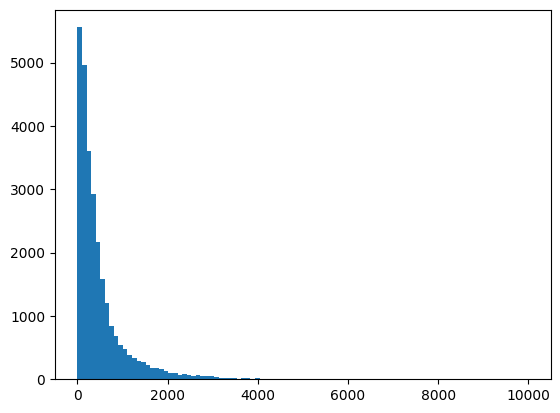

In [106]:
import matplotlib.pyplot as plt
plt.hist(synthetic_df['density'], bins=np.linspace(0, 1e4, 100))
plt.show()

In [99]:
synthetic_df['density']

0        10943.7
1         3165.8
2         4590.3
3         4791.1
4         1386.5
          ...   
30779       17.9
30780        0.0
30781        1.8
30782       13.1
30783        0.4
Name: density, Length: 30784, dtype: float64

In [43]:
simulation_df.dropna()

,location,date,fatalities,injured,total_victims,population,density,arm_count,arms_density
0,"Winder, Georgia",9/4/24,4,9,13,18847.0,505.4,8.0,0.214528
1,"Fordyce, Arkansas",6/21/24,4,10,14,3320.0,190.6,2.0,0.114819
2,"Las Vegas, Nevada",12/6/23,3,1,4,2256509.0,1771.5,59.0,0.046319
3,"Lewiston, Maine",10/25/23,18,13,31,37886.0,428.4,1.0,0.011308
4,"Jacksonville, Florida",8/26/23,3,0,3,1303156.0,496.9,54.0,0.020590
...,...,...,...,...,...,...,...,...,...
145,"Sunnyvale, California",2/16/1988,7,4,11,153455.0,2685.8,8.0,0.140018
146,"Palm Bay, Florida",4/23/1987,6,14,20,547659.0,558.0,10.0,0.010189
147,"Edmond, Oklahoma",8/20/1986,15,6,21,95618.0,437.2,40.0,0.182894
149,"Dallas, Texas",6/29/1984,6,1,7,5843632.0,1477.2,52.0,0.013145


In [9]:
known_cs = set((c.lower(), s.lower()) for c, s in zip(city_df['city'], city_df['state_name']))
shootings_cs = []
for l in mj_shootings['location']:
    c, s = tuple(l.split(', '))
    shootings_cs.append((c.lower(), s.lower()))

In [ ]:
len(shootings_cs), len(set(shootings_cs)), len(known_cs.intersection(shootings_cs))
print(set(shootings_cs).difference(known_cs.intersection(shootings_cs)))

(151, 136, 121)